In [2]:
import pandas as pd


data = pd.read_csv('../data/recipes_data.csv')

display(data)


FileNotFoundError: [Errno 2] No such file or directory: '../data/recipes_data.csv'

In [4]:
# Vectorize recipe ingredients using Food2Vec
# Choose up to 200 random recipes and vectorize their ingredients for testing
import ast
import numpy as np
from food2vec.semantic_nutrition import Estimator

SAMPLE_SIZE = 200
RANDOM_SEED = 42


def normalize_ingredients(raw_ingredients):
    """Convert ingredient input to a single ';'-separated string for one embedding vector."""
    if pd.isna(raw_ingredients):
        return ""

    # Handle stringified lists from CSV (e.g., "['salt', 'pepper']")
    if isinstance(raw_ingredients, str):
        text = raw_ingredients.strip()
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (list, tuple, set)):
                ingredients_list = list(parsed)
            else:
                ingredients_list = [text]
        except Exception:
            # Fall back to common separators if parsing fails
            if ";" in text:
                ingredients_list = text.split(";")
            elif "," in text:
                ingredients_list = text.split(",")
            else:
                ingredients_list = [text]
    elif isinstance(raw_ingredients, (list, tuple, set)):
        ingredients_list = list(raw_ingredients)
    else:
        ingredients_list = [str(raw_ingredients)]

    cleaned = [str(x).strip().lower() for x in ingredients_list if str(x).strip()]
    return "; ".join(cleaned)


# Sample recipes for quick testing while building the ranking algorithm
sampled_recipes = data.sample(n=min(SAMPLE_SIZE, len(data)), random_state=RANDOM_SEED).copy()
sampled_recipes["ingredient_text"] = sampled_recipes["ingredients"].apply(normalize_ingredients)

# Food2Vec estimator (semantic nutrition model)
estimator = Estimator()


def safe_embed(text):
    try:
        return estimator.embed(text)
    except Exception:
        return None


sampled_recipes["embedding"] = sampled_recipes["ingredient_text"].apply(safe_embed)
vectorized_recipes = sampled_recipes[sampled_recipes["embedding"].notna()].copy()

# Useful testing artifacts for later top-K retrieval
if len(vectorized_recipes) > 0:
    recipe_matrix = np.vstack(vectorized_recipes["embedding"].to_list())
else:
    recipe_matrix = np.empty((0, 0))

print(f"Sampled recipes: {len(sampled_recipes)}")
print(f"Successfully vectorized: {len(vectorized_recipes)}")
print(f"Embedding matrix shape: {recipe_matrix.shape}")

display(vectorized_recipes[["title", "ingredient_text"]].head())

------ALERT--------
You're using demonstration nutrition data. This is a random subset (~100 items) from our annotated database.
We do not have permission to distribute our full dataset, and we recommend processing your own.
The USDA provides an excellent start: https://fdc.nal.usda.gov/
You can suppress this warning by setting the 'demo_warning' parameter to False.
-------------------
Sampled recipes: 200
Successfully vectorized: 200
Embedding matrix shape: (200, 300)


,title,ingredient_text
2015528,Marinated Flank Steak Recipe,1 1/2 pound flank steak; 1/2 c. finely minced ...
1608734,French Chicken Stew,1 tablespoon rosemary; 1 teaspoon thyme; 3 bay...
778500,Glazed Carrots,3 to 4 carrots; 1 1/2 tbsp. butter; 1/3 c. bro...
1334975,Moms Pie Dough,4.5 cups flour; 1.5 tsp salt; pinch baking pow...
116562,Pretzel Salad Or Dessert,2 c. crushed small thin pretzels (sticks); 3/4...


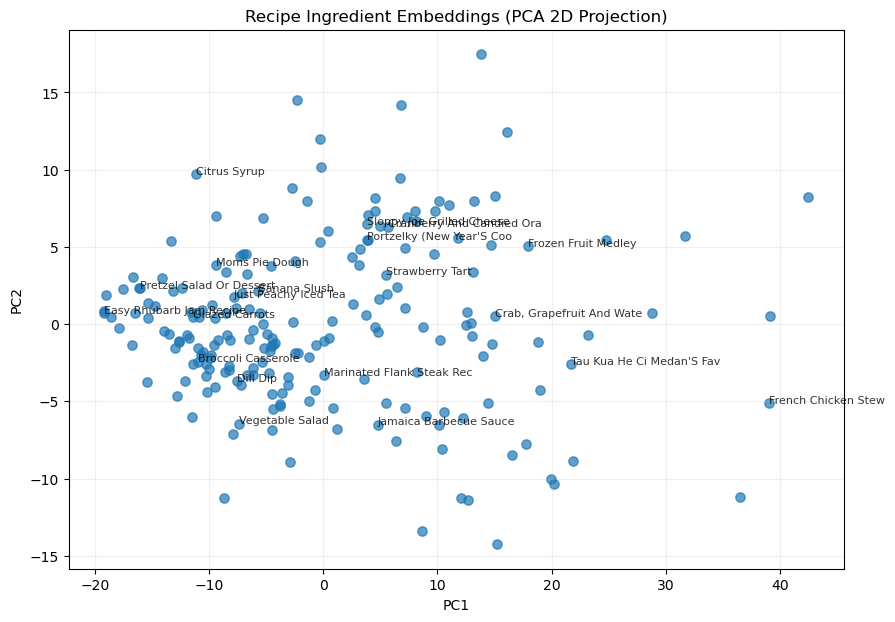

Nearest recipes to:
  Marinated Flank Steak Recipe

Top neighbors (cosine distance, lower is more similar):
1. Marinated Flank Steak Recipe | distance=0.0000
2. Grilled Soft Shelled Crab With Shrimp Mayo | distance=0.1007
3. Mustard Plus Glazed Pork Chops | distance=0.1017
4. Rice And Asparagus Salad  | distance=0.1111


In [5]:
# Visualize embedding proximity: recipes with similar ingredients should appear close in 2D
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

if recipe_matrix.shape[0] < 2:
    print("Need at least 2 vectorized recipes to visualize distances.")
else:
    # Reduce high-dimensional vectors to 2D for plotting
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    coords_2d = pca.fit_transform(recipe_matrix)

    viz_df = vectorized_recipes[["title", "ingredient_text"]].copy().reset_index(drop=True)
    viz_df["x"] = coords_2d[:, 0]
    viz_df["y"] = coords_2d[:, 1]

    plt.figure(figsize=(10, 7))
    plt.scatter(viz_df["x"], viz_df["y"], alpha=0.7, s=45)

    # Annotate a subset to keep the chart readable
    max_labels = min(20, len(viz_df))
    for i in range(max_labels):
        plt.annotate(viz_df.loc[i, "title"][:25], (viz_df.loc[i, "x"], viz_df.loc[i, "y"]), fontsize=8, alpha=0.8)

    plt.title("Recipe Ingredient Embeddings (PCA 2D Projection)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(alpha=0.2)
    plt.show()

    # Quantitative sanity check: nearest neighbors in embedding space
    knn = NearestNeighbors(n_neighbors=min(4, len(recipe_matrix)), metric="cosine")
    knn.fit(recipe_matrix)

    sample_idx = 0
    distances, indices = knn.kneighbors(recipe_matrix[sample_idx:sample_idx + 1])

    print("Nearest recipes to:")
    print(f"  {viz_df.loc[sample_idx, 'title']}")
    print("\nTop neighbors (cosine distance, lower is more similar):")
    for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1):
        print(f"{rank}. {viz_df.loc[idx, 'title']} | distance={dist:.4f}")

Cosine similarity matrix (higher = closer):


name,apple,pear,orange,beef,chicken_lemon,chicken_lime,caprese,italian_tomato,cucumber_dill,beef_stirfry
name,,,,,,,,,,
apple,1.000,0.645,0.392,0.240,0.596,0.531,0.445,0.445,0.416,0.407
pear,0.645,1.000,0.364,0.286,0.647,0.603,0.451,0.451,0.474,0.481
orange,0.392,0.364,1.000,0.087,0.510,0.503,0.405,0.405,0.269,0.277
beef,0.240,0.286,0.087,1.000,0.153,0.162,0.195,0.195,0.308,0.414
chicken_lemon,0.596,0.647,0.510,0.153,1.000,0.863,0.725,0.725,0.561,0.523
chicken_lime,0.531,0.603,0.503,0.162,0.863,1.000,0.711,0.711,0.519,0.478
caprese,0.445,0.451,0.405,0.195,0.725,0.711,1.000,1.000,0.432,0.499
italian_tomato,0.445,0.451,0.405,0.195,0.725,0.711,1.000,1.000,0.432,0.499
cucumber_dill,0.416,0.474,0.269,0.308,0.561,0.519,0.432,0.432,1.000,0.829


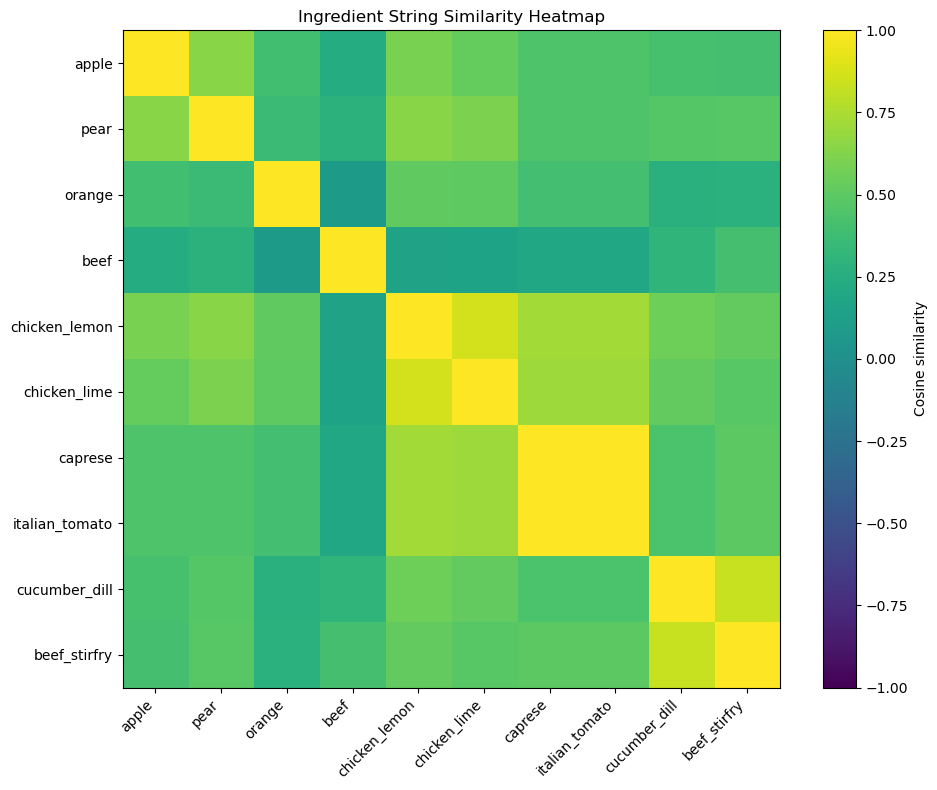


Expected close-vs-far checks:
PASS: apple -> close(pear)=0.645, far(beef)=0.240
PASS: chicken_lemon -> close(chicken_lime)=0.863, far(beef_stirfry)=0.523
PASS: caprese -> close(italian_tomato)=1.000, far(beef_stirfry)=0.499

Top 2 nearest neighbors per item:
apple: pear (0.645), chicken_lemon (0.596)
pear: chicken_lemon (0.647), apple (0.645)
orange: chicken_lemon (0.510), chicken_lime (0.503)
beef: beef_stirfry (0.414), cucumber_dill (0.308)
chicken_lemon: chicken_lime (0.863), caprese (0.725)
chicken_lime: chicken_lemon (0.863), caprese (0.711)
caprese: italian_tomato (1.000), chicken_lemon (0.725)
italian_tomato: caprese (1.000), chicken_lemon (0.725)
cucumber_dill: beef_stirfry (0.829), chicken_lemon (0.561)
beef_stirfry: cucumber_dill (0.829), chicken_lemon (0.523)


In [6]:
# Controlled similarity checks on single ingredients and ingredient lists
from sklearn.metrics.pairwise import cosine_similarity

# Each text is a single embedding input using ';' as requested
test_items = [
    {"name": "apple", "text": "apple"},
    {"name": "pear", "text": "pear"},
    {"name": "orange", "text": "orange"},
    {"name": "beef", "text": "beef"},
    {"name": "chicken_lemon", "text": "chicken; garlic; olive oil; lemon"},
    {"name": "chicken_lime", "text": "chicken; garlic; olive oil; lime"},
    {"name": "caprese", "text": "tomato; basil; mozzarella; olive oil"},
    {"name": "italian_tomato", "text": "tomato; basil; parmesan; olive oil"},
    {"name": "cucumber_dill", "text": "cucumber; dill; yogurt; garlic"},
    {"name": "beef_stirfry", "text": "beef; soy sauce; ginger; garlic"},
]

test_df = pd.DataFrame(test_items)

def embed_or_none(text):
    try:
        return estimator.embed(text)
    except Exception:
        return None

test_df["embedding"] = test_df["text"].apply(embed_or_none)
test_df = test_df[test_df["embedding"].notna()].reset_index(drop=True)

if len(test_df) < 2:
    print("Not enough successful test embeddings to compare.")
else:
    test_matrix = np.vstack(test_df["embedding"].to_list())
    sim = cosine_similarity(test_matrix)
    sim_df = pd.DataFrame(sim, index=test_df["name"], columns=test_df["name"])

    print("Cosine similarity matrix (higher = closer):")
    display(sim_df.round(3))

    # Visual heatmap for quick inspection
    plt.figure(figsize=(10, 8))
    plt.imshow(sim, cmap="viridis", vmin=-1, vmax=1)
    plt.colorbar(label="Cosine similarity")
    plt.xticks(range(len(test_df)), test_df["name"], rotation=45, ha="right")
    plt.yticks(range(len(test_df)), test_df["name"])
    plt.title("Ingredient String Similarity Heatmap")
    plt.tight_layout()
    plt.show()

    # Expected behavior checks: close pair should score higher than far pair
    checks = [
        ("apple", "pear", "beef"),
        ("chicken_lemon", "chicken_lime", "beef_stirfry"),
        ("caprese", "italian_tomato", "beef_stirfry"),
    ]

    print("\nExpected close-vs-far checks:")
    for anchor, expected_close, expected_far in checks:
        if anchor in sim_df.index and expected_close in sim_df.index and expected_far in sim_df.index:
            close_score = sim_df.loc[anchor, expected_close]
            far_score = sim_df.loc[anchor, expected_far]
            passed = close_score > far_score
            result = "PASS" if passed else "CHECK"
            print(
                f"{result}: {anchor} -> close({expected_close})={close_score:.3f}, "
                f"far({expected_far})={far_score:.3f}"
            )

    # Top neighbors for each test item (excluding itself)
    print("\nTop 2 nearest neighbors per item:")
    for name in sim_df.index:
        neighbors = sim_df.loc[name].drop(name).sort_values(ascending=False).head(2)
        neighbor_text = ", ".join([f"{n} ({s:.3f})" for n, s in neighbors.items()])
        print(f"{name}: {neighbor_text}")

Benchmark checks evaluated: 10
Pass rate: 100.0%


,tag,anchor,expected_close,expected_far,close_score,far_score,margin,pass
0,substitute_dairy_single,yogurt,sour_cream,beef,0.379993,0.317173,0.062819,True
1,beef_recipe_cluster,beef_stirfry,beef_teriyaki,caprese,0.787104,0.668045,0.119059,True
2,creamy_herb_cluster,tzatziki,creamy_cucumber,beef_stirfry,0.567398,0.415778,0.151619,True
3,fruit_vs_fish,banana,apple,salmon,0.531841,0.264675,0.267166,True
4,italian_recipe_cluster,caprese,italian_tomato,beef_stirfry,1.000000,0.668045,0.331955,True
5,substitute_single_acid,lemon_juice,vinegar,beef,0.556773,0.195890,0.360883,True
6,chicken_citrus_cluster,chicken_lemon,chicken_lime,beef_stirfry,0.923219,0.518069,0.405150,True
7,fruit_vs_meat,apple,pear,beef,0.645070,0.239838,0.405232,True
8,substitute_recipe_acid,chicken_lemon,chicken_vinegar,beef_stirfry,0.930230,0.518069,0.412161,True
9,substitute_citrus_single,lemon_juice,lime_juice,beef,0.845150,0.195890,0.649260,True



Substitute-focused similarity values:
lemon_juice <-> vinegar: 0.557
lemon_juice <-> lime_juice: 0.845
chicken_lemon <-> chicken_vinegar: 0.930
yogurt <-> sour_cream: 0.380


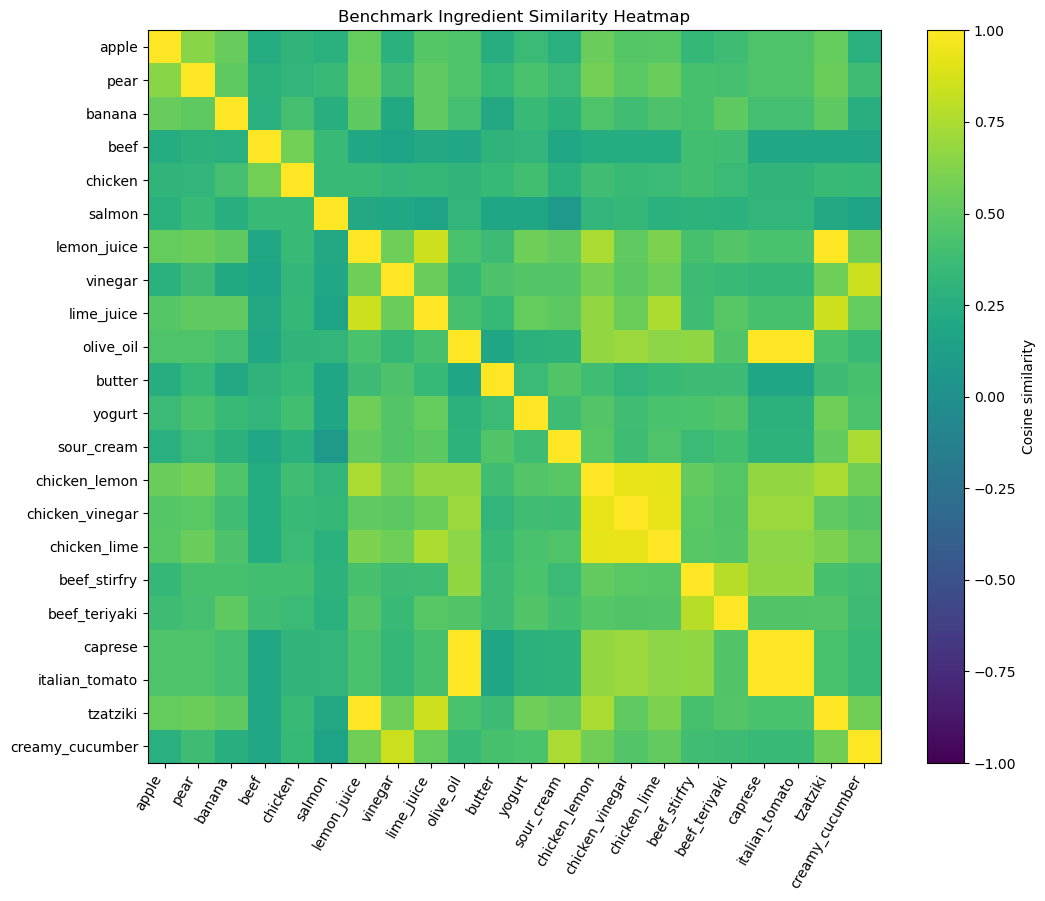

In [7]:
# Larger benchmark: close-vs-far checks including ingredient substitutes
from sklearn.metrics.pairwise import cosine_similarity

benchmark_items = [
    # single ingredients
    {"name": "apple", "text": "apple"},
    {"name": "pear", "text": "pear"},
    {"name": "banana", "text": "banana"},
    {"name": "beef", "text": "beef"},
    {"name": "chicken", "text": "chicken"},
    {"name": "salmon", "text": "salmon"},
    # substitute-focused singles
    {"name": "lemon_juice", "text": "lemon juice"},
    {"name": "vinegar", "text": "vinegar"},
    {"name": "lime_juice", "text": "lime juice"},
    {"name": "olive_oil", "text": "olive oil"},
    {"name": "butter", "text": "butter"},
    {"name": "yogurt", "text": "yogurt"},
    {"name": "sour_cream", "text": "sour cream"},
    # multi-ingredient recipes
    {"name": "chicken_lemon", "text": "chicken; garlic; olive oil; lemon juice; salt"},
    {"name": "chicken_vinegar", "text": "chicken; garlic; olive oil; vinegar; salt"},
    {"name": "chicken_lime", "text": "chicken; garlic; olive oil; lime juice; salt"},
    {"name": "beef_stirfry", "text": "beef; soy sauce; ginger; garlic; sesame oil"},
    {"name": "beef_teriyaki", "text": "beef; soy sauce; garlic; ginger; sugar"},
    {"name": "caprese", "text": "tomato; basil; mozzarella; olive oil"},
    {"name": "italian_tomato", "text": "tomato; basil; parmesan; olive oil"},
    {"name": "tzatziki", "text": "yogurt; cucumber; garlic; dill; lemon juice"},
    {"name": "creamy_cucumber", "text": "sour cream; cucumber; garlic; dill; vinegar"},
]

bench_df = pd.DataFrame(benchmark_items)


def embed_safe(text):
    try:
        return estimator.embed(text)
    except Exception:
        return None


bench_df["embedding"] = bench_df["text"].apply(embed_safe)
bench_df = bench_df[bench_df["embedding"].notna()].reset_index(drop=True)

if len(bench_df) < 3:
    print("Need at least 3 successful benchmark embeddings.")
else:
    bench_matrix = np.vstack(bench_df["embedding"].to_list())
    bench_sim = cosine_similarity(bench_matrix)
    bench_sim_df = pd.DataFrame(bench_sim, index=bench_df["name"], columns=bench_df["name"])

    # Define expected close-vs-far relationships
    benchmark_checks = [
        ("apple", "pear", "beef", "fruit_vs_meat"),
        ("banana", "apple", "salmon", "fruit_vs_fish"),
        ("beef_stirfry", "beef_teriyaki", "caprese", "beef_recipe_cluster"),
        ("caprese", "italian_tomato", "beef_stirfry", "italian_recipe_cluster"),
        ("chicken_lemon", "chicken_lime", "beef_stirfry", "chicken_citrus_cluster"),
        ("tzatziki", "creamy_cucumber", "beef_stirfry", "creamy_herb_cluster"),
        # Substitute checks requested
        ("lemon_juice", "vinegar", "beef", "substitute_single_acid"),
        ("lemon_juice", "lime_juice", "beef", "substitute_citrus_single"),
        ("chicken_lemon", "chicken_vinegar", "beef_stirfry", "substitute_recipe_acid"),
        ("yogurt", "sour_cream", "beef", "substitute_dairy_single"),
    ]

    rows = []
    for anchor, expected_close, expected_far, tag in benchmark_checks:
        if anchor in bench_sim_df.index and expected_close in bench_sim_df.index and expected_far in bench_sim_df.index:
            close_score = float(bench_sim_df.loc[anchor, expected_close])
            far_score = float(bench_sim_df.loc[anchor, expected_far])
            margin = close_score - far_score
            passed = close_score > far_score
            rows.append(
                {
                    "tag": tag,
                    "anchor": anchor,
                    "expected_close": expected_close,
                    "expected_far": expected_far,
                    "close_score": close_score,
                    "far_score": far_score,
                    "margin": margin,
                    "pass": passed,
                }
            )

    results_df = pd.DataFrame(rows)

    if len(results_df) == 0:
        print("No benchmark checks could be evaluated with available embeddings.")
    else:
        pass_rate = results_df["pass"].mean()
        print(f"Benchmark checks evaluated: {len(results_df)}")
        print(f"Pass rate: {pass_rate:.1%}")

        # Show worst margins first to spot weak semantic behavior quickly
        display(results_df.sort_values(["pass", "margin"], ascending=[True, True]).reset_index(drop=True))

        print("\nSubstitute-focused similarity values:")
        substitute_pairs = [
            ("lemon_juice", "vinegar"),
            ("lemon_juice", "lime_juice"),
            ("chicken_lemon", "chicken_vinegar"),
            ("yogurt", "sour_cream"),
        ]
        for a, b in substitute_pairs:
            if a in bench_sim_df.index and b in bench_sim_df.index:
                print(f"{a} <-> {b}: {bench_sim_df.loc[a, b]:.3f}")

        # Heatmap for benchmark set
        plt.figure(figsize=(11, 9))
        plt.imshow(bench_sim, cmap="viridis", vmin=-1, vmax=1)
        plt.colorbar(label="Cosine similarity")
        plt.xticks(range(len(bench_df)), bench_df["name"], rotation=60, ha="right")
        plt.yticks(range(len(bench_df)), bench_df["name"])
        plt.title("Benchmark Ingredient Similarity Heatmap")
        plt.tight_layout()
        plt.show()

In [9]:
# Build and save a full-dataset vector set for retrieval (pgvector-friendly JSONL)
import json
from pathlib import Path

EXPORT_SIZE = len(data)
EXPORT_SEED = 42
export_path = Path("../data/recipe_vectors_all.jsonl")

# Sample full dataset (randomized order) for export
export_recipes = data.sample(n=min(EXPORT_SIZE, len(data)), random_state=EXPORT_SEED).copy().reset_index(drop=True)
export_recipes["ingredient_text"] = export_recipes["ingredients"].apply(normalize_ingredients)

# Keep estimator usage consistent with earlier cells
export_recipes["embedding"] = export_recipes["ingredient_text"].apply(safe_embed)
export_recipes = export_recipes[export_recipes["embedding"].notna()].reset_index(drop=True)

# Add stable local id for easier DB loading and indexing
export_recipes["recipe_id"] = export_recipes.index.astype(int)

# Persist as JSONL: one record per line with vector list
# This structure maps directly to pgvector inserts later.
records = []
for _, row in export_recipes.iterrows():
    records.append(
        {
            "recipe_id": int(row["recipe_id"]),
            "title": str(row.get("title", "")),
            "ingredient_text": str(row.get("ingredient_text", "")),
            "directions": str(row.get("directions", "")),
            "link": str(row.get("link", "")),
            "source": str(row.get("source", "")),
            "embedding": list(map(float, row["embedding"])),
        }
    )

export_path.parent.mkdir(parents=True, exist_ok=True)
with export_path.open("w", encoding="utf-8") as f:
    for rec in records:
        f.write(json.dumps(rec) + "\n")

print(f"Saved vector set to: {export_path.resolve()}")
print(f"Requested sample size: {EXPORT_SIZE}")
print(f"Saved records: {len(records)}")
if len(records) > 0:
    print(f"Embedding dimension: {len(records[0]['embedding'])}")

Saved vector set to: C:\Users\yotam\school\csce470\MagniFood\data\recipe_vectors_all.jsonl
Requested sample size: 2231142
Saved records: 2230700
Embedding dimension: 300
